In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import (
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

import warnings

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [4]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [6]:
preprocessamento = Pipeline(
    steps=[("scaler", PowerTransformer())]
)

In [7]:
classificadores = {
    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "Perceptron": {
        "preprocessor": preprocessamento,
        "classificador": Perceptron()
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },

    "SGDClassifier": {
        "preprocessor": preprocessamento,
        "classificador": SGDClassifier()
    },
    
}

In [8]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados.head(10)

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.001091,0.007011,0.526316,0.472977,0.289474,0.333333,0.255814,0.554373,0.40767,0.008102
1,DummyClassifier,0.000706,0.004009,0.578947,0.528988,0.368421,0.424242,0.325581,0.512447,0.383313,0.004715
2,DummyClassifier,0.000367,0.003335,0.54386,0.519841,0.409091,0.391304,0.428571,0.516865,0.376735,0.003702
3,DummyClassifier,0.000328,0.003119,0.412281,0.371032,0.211765,0.209302,0.214286,0.627976,0.452922,0.003447
4,DummyClassifier,0.000416,0.003425,0.548673,0.529007,0.426966,0.404255,0.452381,0.493796,0.368833,0.00384
5,Perceptron,0.049192,0.007152,0.947368,0.953161,0.933333,0.893617,0.976744,0.992139,0.98945,0.056344
6,Perceptron,0.025743,0.008841,0.964912,0.96266,0.953488,0.953488,0.953488,0.99869,0.997909,0.034584
7,Perceptron,0.030636,0.008314,0.947368,0.943452,0.928571,0.928571,0.928571,0.982474,0.977233,0.038949
8,Perceptron,0.026476,0.012038,0.973684,0.979167,0.965517,0.933333,1.0,1.0,1.0,0.038514
9,Perceptron,0.043375,0.012559,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.055935


In [9]:
df_resultados.groupby("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.000582,0.00418,0.522015,0.484369,0.341143,0.352488,0.335327,0.541091,0.397895,0.004761
LogisticRegression,0.04987,0.01241,0.975408,0.970873,0.96636,0.981258,0.952935,0.996632,0.995721,0.06228
SGDClassifier,0.036773,0.009359,0.963127,0.962926,0.951372,0.943013,0.962237,0.994781,0.992985,0.046132
Perceptron,0.035084,0.009781,0.966667,0.967688,0.956182,0.941802,0.971761,0.99466,0.992919,0.044865


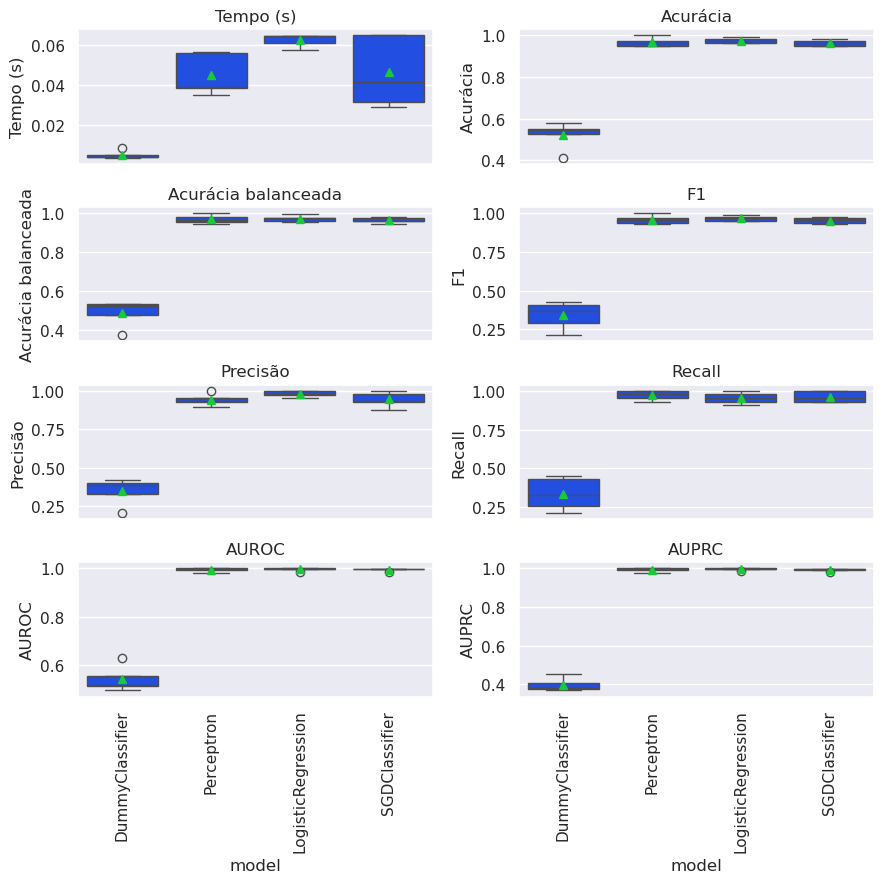

In [10]:
plot_comparar_metricas_modelos(df_resultados)

In [11]:
param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2", "elasticnet", None],
    "clf__class_weight": [None, "balanced"],
    "clf__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9],
}

In [12]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="recall"
)

grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer())])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [13]:
warnings.filterwarnings('ignore')
grid_search.fit(X, y)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/hilario/anaconda3/envs/MachineLearning/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarn

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer())])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [14]:
grid_search.best_params_

{'clf__C': 0.1,
 'clf__class_weight': 'balanced',
 'clf__l1_ratio': 0.1,
 'clf__penalty': 'l2'}

In [15]:
grid_search.best_score_

0.9623477297895903

In [16]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', PowerTransformer())])),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    l1_ratio=0.1, random_state=42,
                                    solver='saga'))])

In [17]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_se', 'compactness_worst', 'concave points_mean',
       'concave points_se', 'concave points_worst', 'concavity_mean',
       'concavity_se', 'concavity_worst', 'fractal_dimension_mean',
       'fractal_dimension_se', 'fractal_dimension_worst',
       'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_mean',
       'radius_se', 'radius_worst', 'smoothness_mean', 'smoothness_se',
       'smoothness_worst', 'symmetry_mean', 'symmetry_se',
       'symmetry_worst', 'texture_mean', 'texture_se', 'texture_worst'],
      dtype=object)

In [18]:
grid_search.best_estimator_["clf"].coef_

array([[ 0.30776287,  0.51249108,  0.45442998, -0.08335921, -0.33172553,
         0.07880288,  0.49038811,  0.13461129,  0.45020865,  0.42494767,
         0.05462929,  0.44867429, -0.18393305, -0.25154422,  0.12127361,
         0.28292901,  0.30080053,  0.39246367,  0.28248957,  0.43920334,
         0.42714151,  0.21077149, -0.04788555,  0.44371669,  0.1529948 ,
        -0.34752492,  0.3884476 ,  0.51214069, -0.0474521 ,  0.60874479]])

In [19]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[0],
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
)

coefs.head(15)

,coeficiente
symmetry_se,-0.347525
compactness_se,-0.331726
fractal_dimension_se,-0.251544
fractal_dimension_mean,-0.183933
compactness_mean,-0.083359
smoothness_se,-0.047886
texture_se,-0.047452
concavity_se,0.054629
compactness_worst,0.078803
fractal_dimension_worst,0.121274


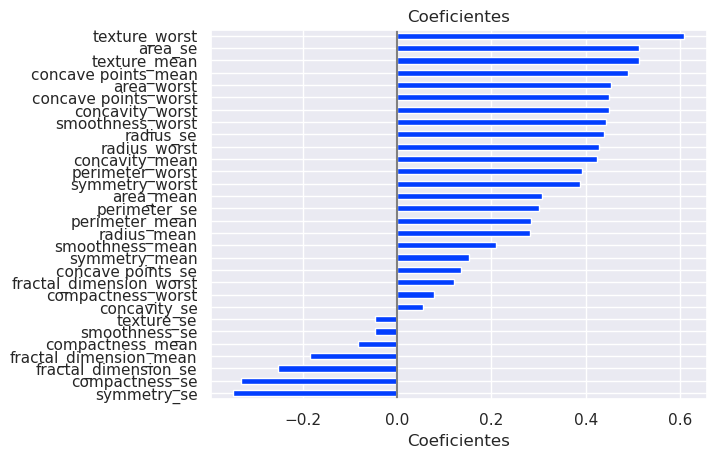

In [20]:
plot_coeficientes(coefs)

Os coeficientes $w_i$ em uma regressão logística não são interpretados diretamente como em uma regressão linear. Em vez disso, eles representam o **logaritmo do odds ratio** associado a cada variável.

- **Odds (Chances):** Razão entre a probabilidade do evento ocorrer e a probabilidade de não ocorrer.

  $$
  \text{Odds} = \frac{\text{Probabilidade do Evento}}{1 - \text{Probabilidade do Evento}}
  $$

- **Odds Ratio:** Medida de quanto as chances mudam com uma unidade de aumento na variável independente.

- **Coeficiente ($w_i$):** Representa a mudança nos **log-odds** do resultado por unidade de aumento na variável $X_i$.

  $$
  \text{Log-Odds} = w_0 + w_1X_1 + w_2X_2 + \dots + w_nX_n
  $$

Para interpretar os coeficientes em termos mais intuitivos, podemos calcular o **exponencial do coeficiente**:

$$
\text{Odds Ratio} = e^{w_i}
$$

- **Interpretação do Odds Ratio:**
  - **Valor > 1:** Aumenta as chances do evento ocorrer.
  - **Valor = 1:** Não afeta as chances.
  - **Valor < 1:** Diminui as chances do evento ocorrer.


Imagine que estamos modelando a probabilidade de um paciente ter uma doença com base na idade e no hábito de fumar.

$$
\text{Log-Odds} = w_0 + w_1 (\text{Idade}) + w_2 (\text{Fumante})
$$

Suponha que obtivemos os seguintes coeficientes:

- $w_0 = -2$
- $w_1 = 0{,}05$
- $w_2 = 1{,}5$

1. **Coeficiente da Idade ($w_1 = 0{,}05$):**

   - **Log-Odds:** Para cada aumento de 1 ano na idade, o log-odds de ter a doença aumenta em 0,05.
   - **Odds Ratio:** $e^{0{,}05} \approx 1{,}051$
   - **Interpretação:** Cada ano adicional de idade aumenta as chances de ter a doença em aproximadamente **5,1%**.

2. **Coeficiente do Fumante ($w_2 = 1{,}5$):**

   - **Log-Odds:** Se o paciente é fumante (1), o log-odds de ter a doença aumenta em 1,5 em comparação com não fumantes (0).
   - **Odds Ratio:** $e^{1{,}5} \approx 4{,}48$
   - **Interpretação:** Fumantes têm **4,48 vezes** mais chances de ter a doença do que não fumantes.


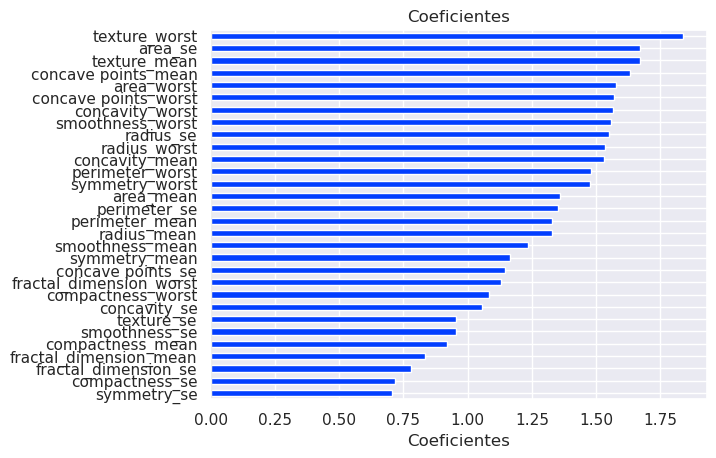

In [21]:
coefs_odd = coefs.copy()
coefs_odd["coeficiente"] = np.exp(coefs_odd["coeficiente"])

plot_coeficientes(coefs_odd)

In [22]:
coefs_odd

,coeficiente
symmetry_se,0.706434
compactness_se,0.717684
fractal_dimension_se,0.777599
fractal_dimension_mean,0.831992
compactness_mean,0.920021
smoothness_se,0.953243
texture_se,0.953656
concavity_se,1.056149
compactness_worst,1.081991
fractal_dimension_worst,1.128934


In [23]:
X_scaled = grid_search.best_estimator_["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out())

X_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1.126421,1.876109,1.652210,2.165938,1.445854,1.942737,1.848558,0.810200,1.935654,1.862988,...,1.619635,1.504114,-0.030553,1.282792,1.953067,1.355589,2.197206,-2.678666,-0.498201,-1.488367
1,1.633946,1.276861,1.610022,-0.384102,-0.793830,-0.296580,0.820609,0.426936,1.101594,0.291976,...,1.578689,-0.820227,-0.633991,-0.325080,0.102291,-1.028611,-0.121997,-0.264377,-0.998312,-0.288382
2,1.461645,1.496107,1.425307,1.163977,1.121521,1.209701,1.683104,1.423361,1.722744,1.403673,...,1.419757,0.963977,-0.148581,0.580301,0.985668,0.568436,1.218181,0.547806,-0.833982,0.071406
3,-0.836238,0.045515,-0.436860,2.197843,1.964874,2.282276,1.423004,1.191720,1.862378,1.642391,...,-0.083692,2.781494,0.975445,2.857821,2.360528,2.350939,3.250202,0.357721,0.097022,0.228089
4,1.595120,1.499885,1.309486,0.762392,0.253010,-0.131829,1.410929,1.214491,0.807077,1.407479,...,1.293727,0.343932,1.545561,0.284367,0.090964,-0.227814,-0.943554,-1.233520,-0.850908,-1.637882


In [24]:
df_scaled = pd.concat([X_scaled, pd.Series(y, name="diagnosis")], axis=1)

df_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst,diagnosis
0,1.126421,1.876109,1.652210,2.165938,1.445854,1.942737,1.848558,0.810200,1.935654,1.862988,...,1.504114,-0.030553,1.282792,1.953067,1.355589,2.197206,-2.678666,-0.498201,-1.488367,1
1,1.633946,1.276861,1.610022,-0.384102,-0.793830,-0.296580,0.820609,0.426936,1.101594,0.291976,...,-0.820227,-0.633991,-0.325080,0.102291,-1.028611,-0.121997,-0.264377,-0.998312,-0.288382,1
2,1.461645,1.496107,1.425307,1.163977,1.121521,1.209701,1.683104,1.423361,1.722744,1.403673,...,0.963977,-0.148581,0.580301,0.985668,0.568436,1.218181,0.547806,-0.833982,0.071406,1
3,-0.836238,0.045515,-0.436860,2.197843,1.964874,2.282276,1.423004,1.191720,1.862378,1.642391,...,2.781494,0.975445,2.857821,2.360528,2.350939,3.250202,0.357721,0.097022,0.228089,1
4,1.595120,1.499885,1.309486,0.762392,0.253010,-0.131829,1.410929,1.214491,0.807077,1.407479,...,0.343932,1.545561,0.284367,0.090964,-0.227814,-0.943554,-1.233520,-0.850908,-1.637882,1


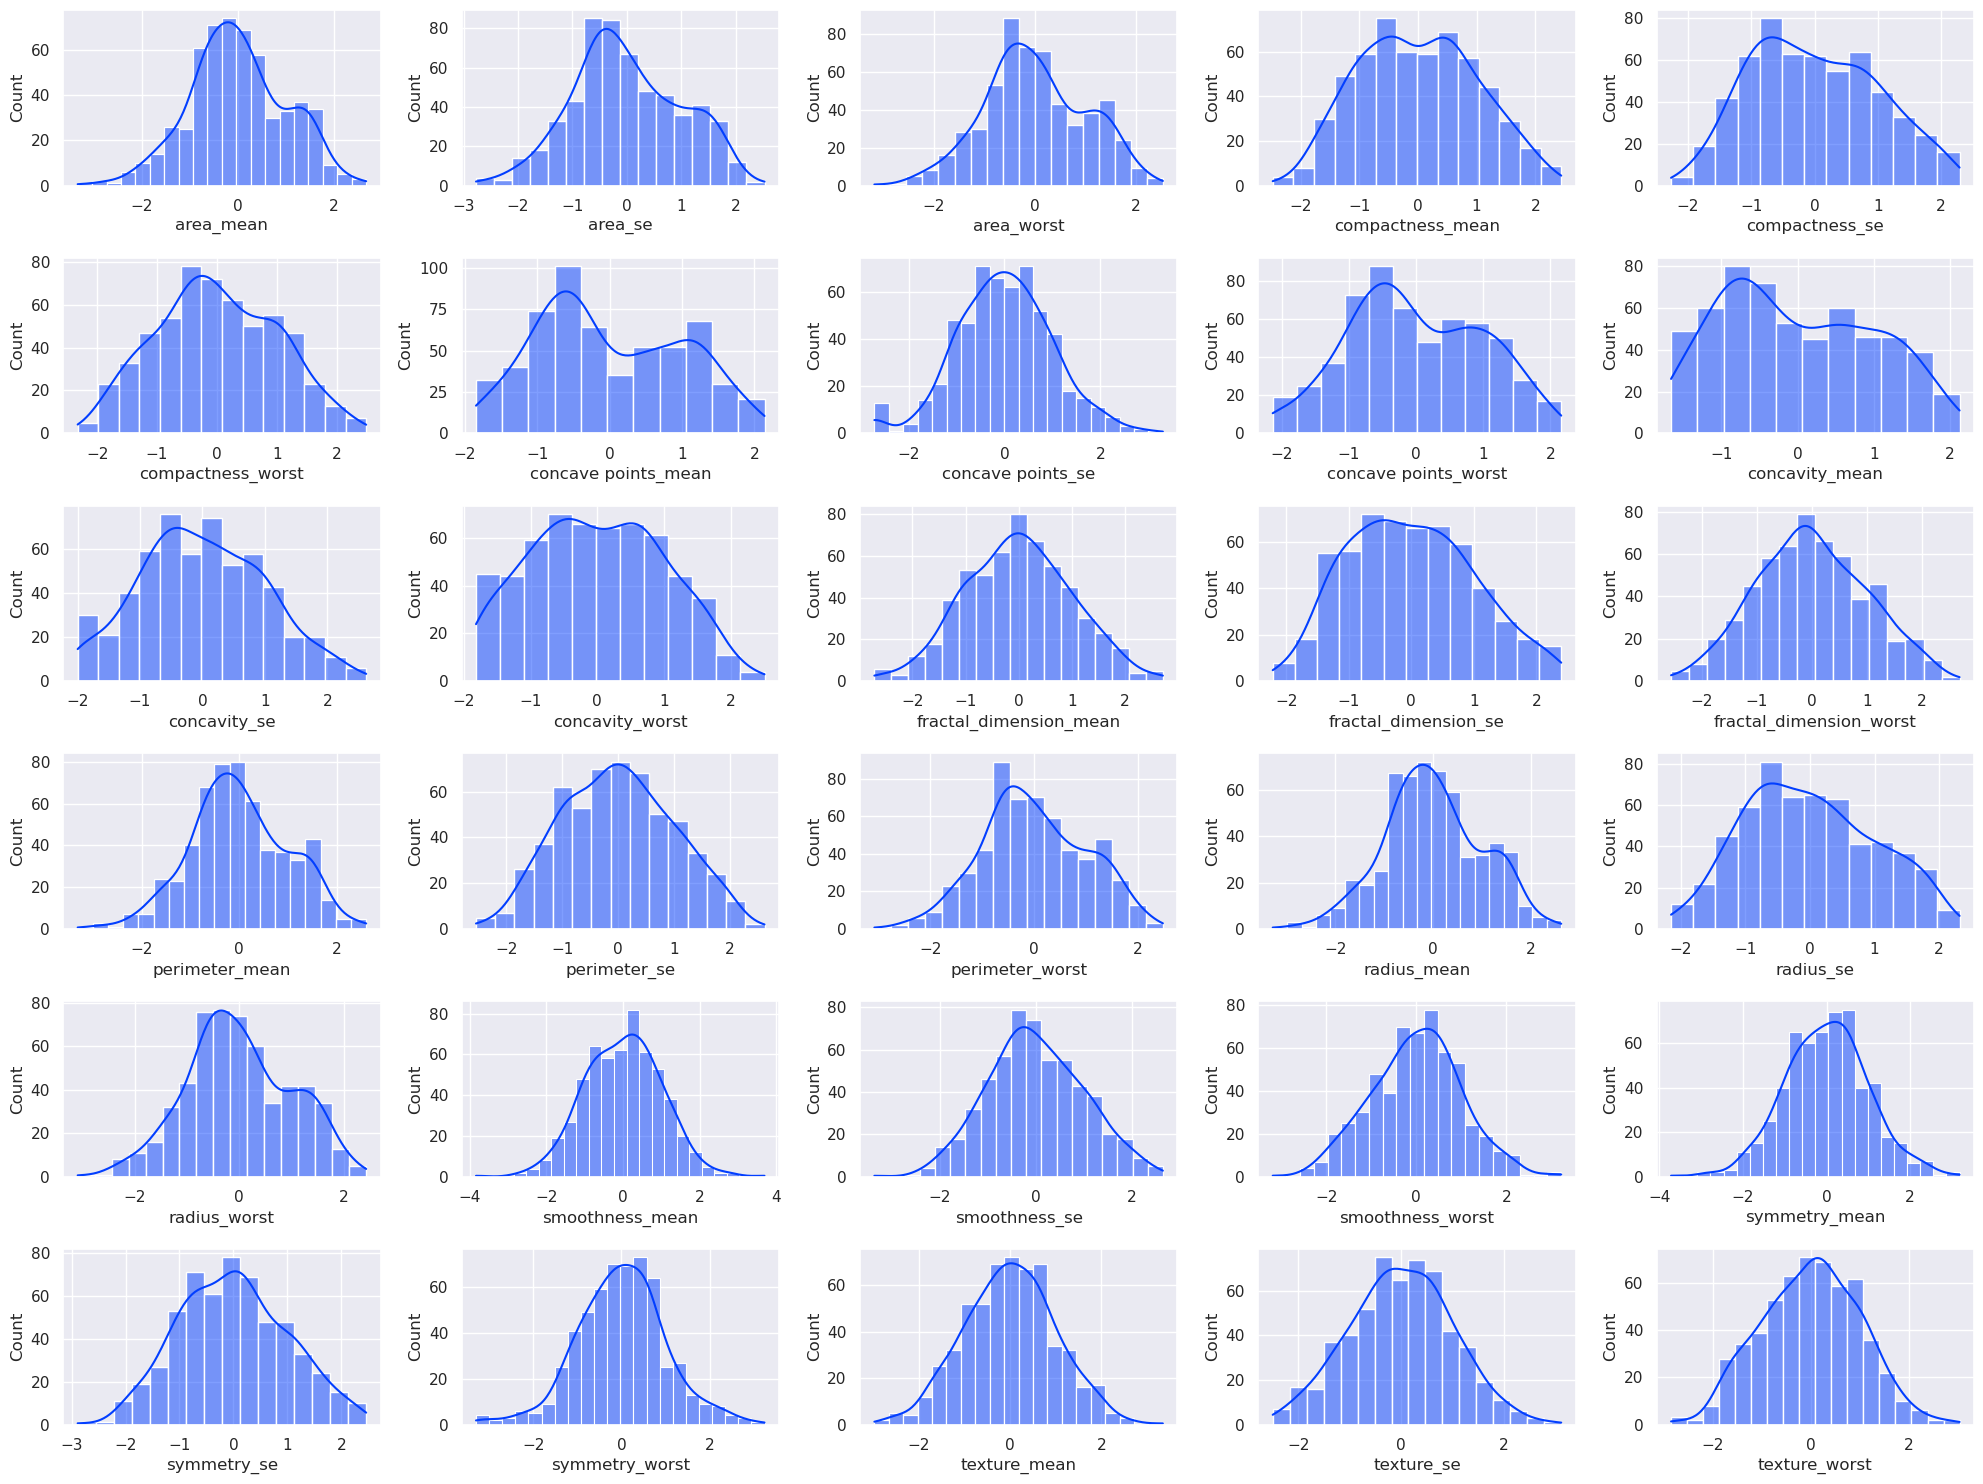

In [25]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), X.columns):
    sns.histplot(x=coluna, ax=ax, data=df_scaled, kde=True)

plt.tight_layout()
plt.show()

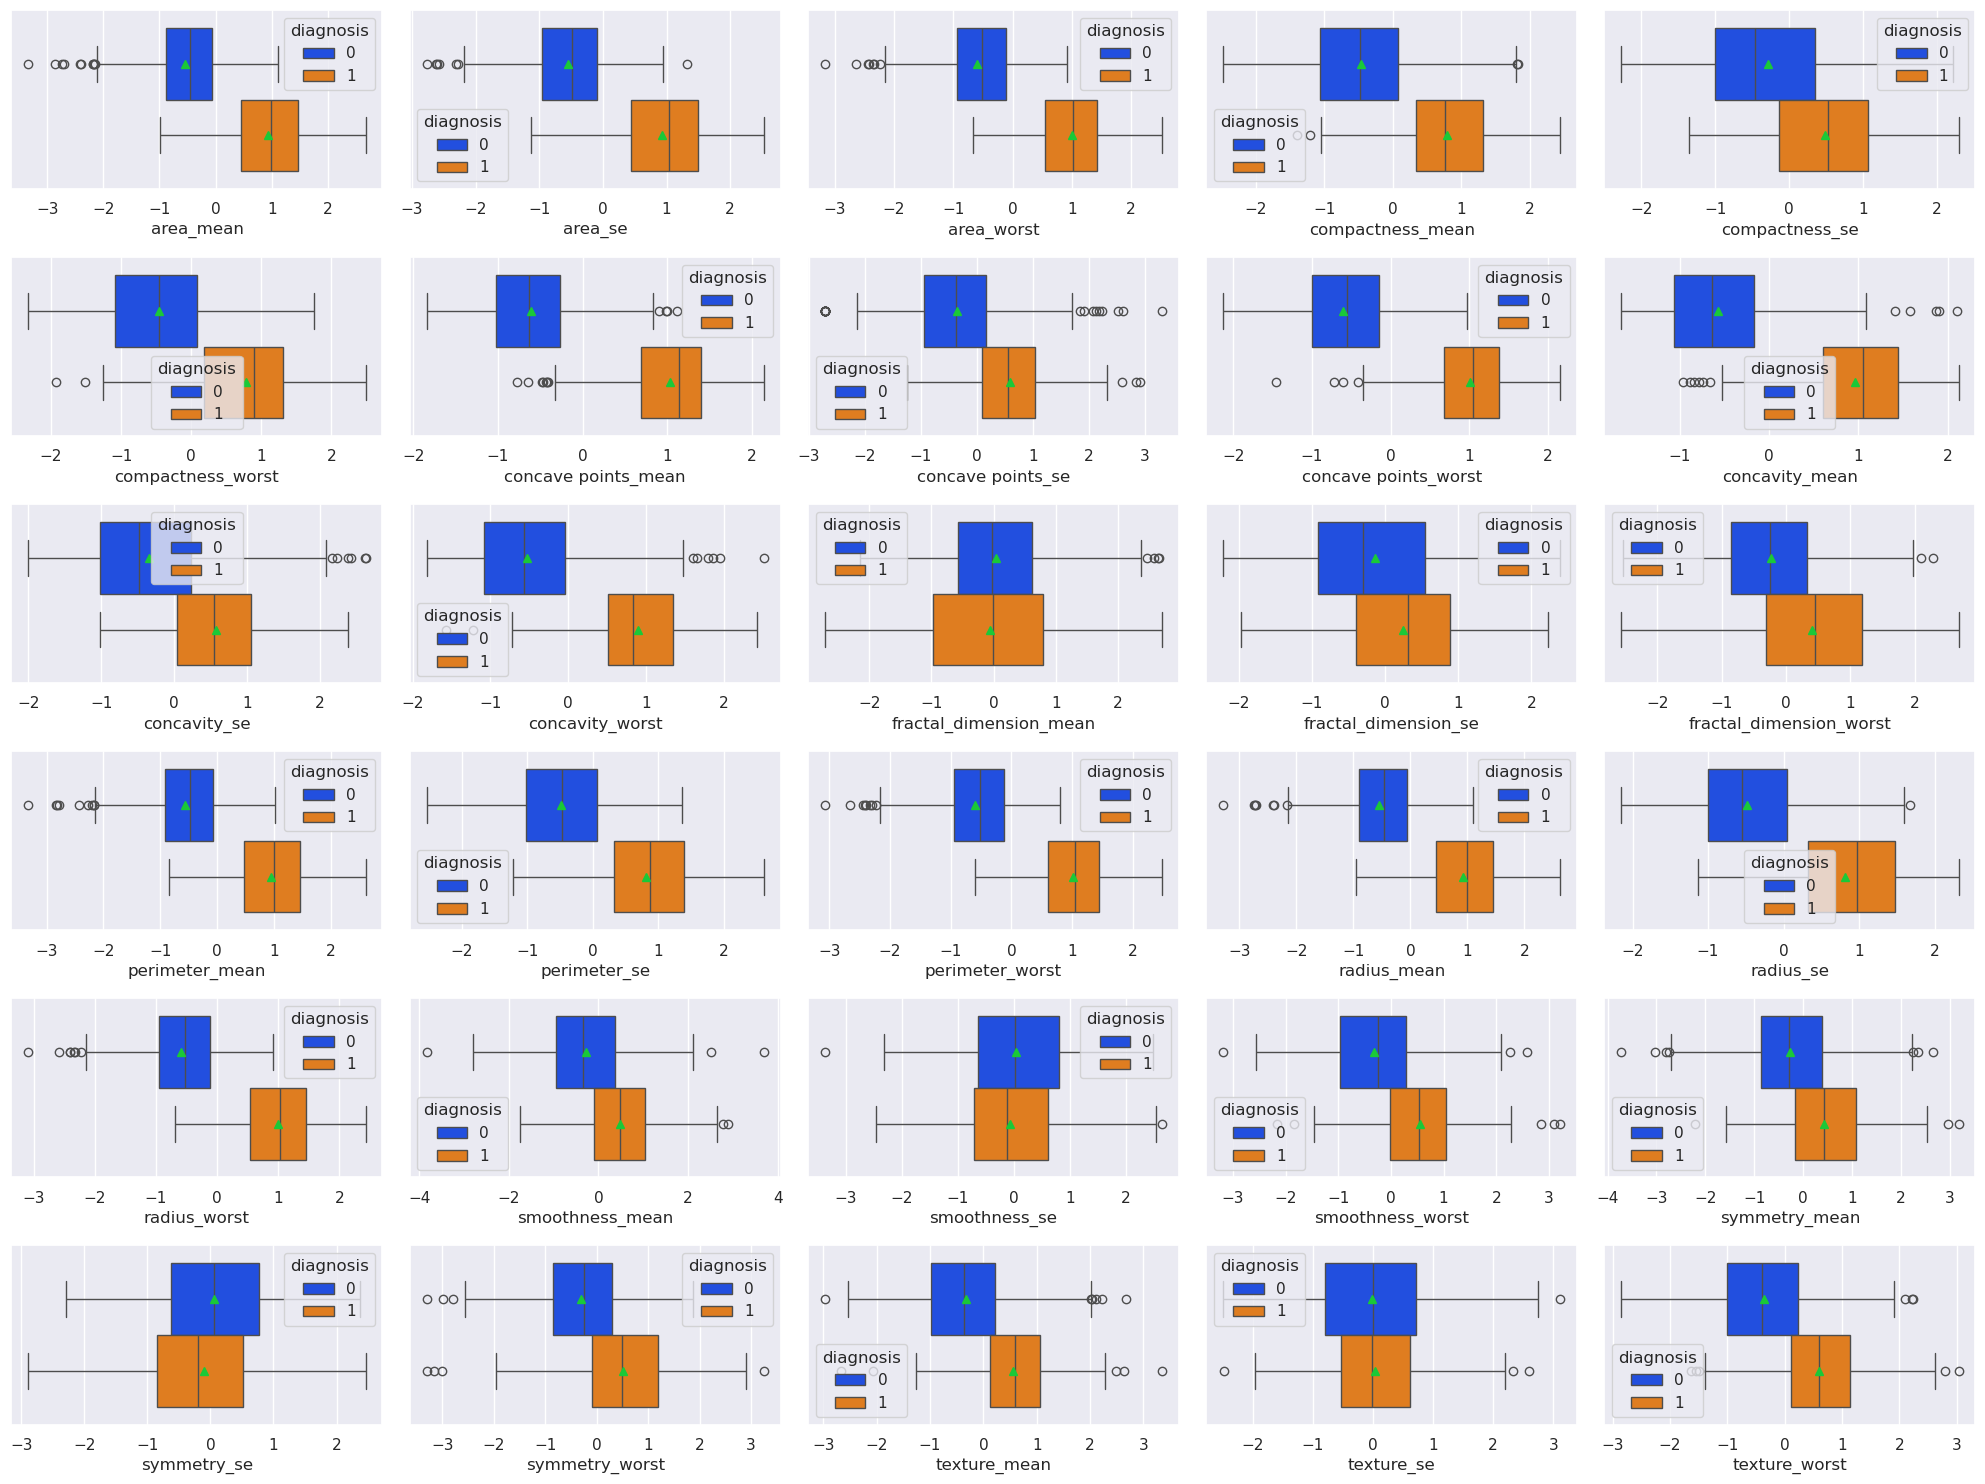

In [26]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), X_scaled.columns):
    sns.boxplot(x=coluna, ax=ax, data=df_scaled, showmeans=True, hue="diagnosis")

plt.tight_layout()
plt.show()